In [40]:
# !pip install -r ../requirements.txt

# CNN Spectrogram Classifier - Training and Q9.15 Golden Model

This notebook owns the CNN branch of the accelerator end to end: it builds
32x32x4 spectrograms from the quantised capture set, trains the float32
reference network, quantises it to Q9.15, writes the ROM images the RTL
loads, and re-runs inference bit-true in NumPy so the SystemVerilog testbench
has a golden result to compare against.

## 1. Where this sits in the hardware

`cnn_inference_path.sv` wires up path B of `top_system`:

```
[ UART sensor frame ]             4 vibration words per frame, Q9.15
          |
          v
[ fir_decimator_32_dualmode ]     /4 -> /4 -> /2, 47/67/83 taps, Q1.17 coeffs
          |
          v
[ sample_buffer_64_hop_dualmode ] 64-sample frames, HOP_SIZE = 64, no overlap
          |
          v
[ mean_remover_64_dualmode ]      removes the frame mean, Q9.15 -> Q10.15
          |
          v
[ hann_window_64_dualmode ]       Q1.17 window, back down to Q9.15
          |
          v
[ fft_shared_4sensor ]            64-point FFT, NORMALIZE = 1, so DFT/64
          |
          v
[ fft_to_stream_adapter x4 ]      keeps bins 0..31, forwards the REAL part
          |
          v
[ spectrogram_generator x4 ]      32 frames x 32 bins per sensor
          |
          v
[ spectrogram_4ch_join ]          one 4-channel pixel per beat
          |
          v
[ cnn_top ]                       Conv2D(4->8, 3x3, pad 1) -> ReLU
                                  -> MaxPool 2x2 -> Flatten(2048) -> Dense(4)
```

The image axes follow that stream order: a **row is one time frame** and a
**column is one frequency bin**, which is why `cnn_inference_path.sv` passes
`IMG_WIDTH = SPEC_BINS` and `IMG_HEIGHT = SPEC_FRAMES`.

The four logits leave `cnn_top` in port order - `m_data_normal`,
`m_data_unbalance`, `m_data_misalign`, `m_data_bearing` - so this notebook
indexes the classes the same way. `inference_arbiter.sv` re-maps them onto the
MLP's own numbering when it forms the system verdict; that translation lives
in the RTL and must not be duplicated here.

## 2. Q9.15 arithmetic

Every sample, coefficient and logit on this path is a 24-bit signed
fixed-point number with 15 fractional bits, matching
`system_types_pkg::DATA_WIDTH` and `mlp_weights_pkg::Q_FRAC`.

| property | value |
| --- | --- |
| word length | 24 bits, two's complement |
| fractional bits | 15 |
| scale | 2^15 = 32768 |
| integer codes | -8388608 .. 8388607 |
| real values | -256.0 .. 255.999969482421875 |
| resolution | 2^-15 ~= 3.0518e-05 |

Quantisation is `q = clip(round(x * 32768), -2^23, 2^23 - 1)`, the same rule
`Scripts/process_dataset/quantize.py` applied to the captures.

`mac_q8_16.sv` accumulates full 48-bit products and shifts only at the end:
`y = saturate24(sum(a_i * b_i) >> 15)`, an arithmetic shift with no rounding,
over an accumulator that wraps at 48 bits. Section 8 reproduces that exactly,
wrap included.

## 3. Two things to know before trusting the exports

**The CNN RTL is still Q8.16.** `mac_q8_16.sv:5`, `cnn_top.sv:14`,
`conv2d_fsm.sv:5` and `dense_layer_fsm.sv:5` all default `FRAC_BITS` to 16,
and the four CNN testbenches override it to 16 as well. Until those become 15
the ROMs written here are read one binary place off. The module name
`mac_q8_16` is a leftover from the same change.

**The dense layer flattens in hardware order, not PyTorch order.**
`dense_layer_fsm.sv:143-152` advances `rom_addr` once per (pixel, channel)
pair while `ch` walks the 8 pooled channels inside each pixel, so the feature
index is `f = (row * 16 + col) * 8 + channel` - pixel-major, channel-minor.
`nn.Flatten` would give `f = channel * 256 + row * 16 + col`. The model below
permutes to `(N, H, W, C)` before flattening so the learned weights land in
the order the ROM reader expects. An archive produced without that permute
addresses the pooled feature map through a scrambled index.

In [41]:
# ============================================================================
# Imports, reproducibility and global configuration
# ============================================================================
from __future__ import annotations

import copy
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def locate_project_root(start: Path) -> Path:
    """Walks up from `start` until both RTL/ and Scripts/ are siblings."""
    for candidate in (start, *start.parents):
        if (candidate / "RTL").is_dir() and (candidate / "Scripts").is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repository root starting at {start}")


PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
NOTEBOOK_DIR = PROJECT_ROOT / "Scripts" / "cnn"

# Q9.15 captures written by Scripts/process_dataset/quantize.py.
DATASET_DIR = PROJECT_ROOT / "Scripts" / "process_dataset" / "dataset_q915" / "vibration"

# The RTL's own coefficient ROMs, reused so the Python front end filters with
# exactly the numbers the hardware filters with.
COEFF_DIR = (PROJECT_ROOT / "RTL" / "FFT"
             / "model_sim_four_modes_quartus_shared_fft" / "coefficients")

CACHE_DIR = NOTEBOOK_DIR / "cache"

# Where the ROM images land. Scripts/cnn/rtl is gitignored scratch space;
# RTL/mem/cnn is the tracked copy Quartus and top_system.sv actually read, so
# promoting a model means copying the four files across. Uncomment the second
# entry to write both in one go.
EXPORT_DIRS = [
    NOTEBOOK_DIR / "rtl",
    # PROJECT_ROOT / "RTL" / "mem" / "cnn",
]

# tb_smma_cnn_top.sv reads this file as ../Scripts/cnn/cnn_tb_input.mem.
TB_INPUT_FILE = NOTEBOOK_DIR / "cnn_tb_input.mem"
MODEL_STATE_FILE = NOTEBOOK_DIR / "cnn_model.pth"
MODEL_Q915_FILE = NOTEBOOK_DIR / "cnn_model_q915.npz"

for directory in (CACHE_DIR, *EXPORT_DIRS):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class order == cnn_top port order. See section 1.
CLASS_NAMES = ["Normal", "Unbalance", "Misalign", "Bearing"]
NUM_CLASSES = len(CLASS_NAMES)

# ---- front-end switches ----------------------------------------------------
# USE_DECIMATOR mirrors the deployed chain: fir_decimator_32_dualmode sits in
# preprocess_window_channel_no_lms.sv. Set it False to train against the
# no-decimator FFT variant instead.
USE_DECIMATOR = False

# The shared four-channel chain has no LMS at all - see the LMS_NOTE in
# dsp_preprocessing_subsystem.sv - so this stays off. It is kept as the one
# surviving filter option because the single-channel pipeline
# preprocess_lms_fft_four_modes.sv does have an eight-tap time-domain LMS.
USE_LMS = True

# fft_to_stream_adapter.sv:52 forwards fft_real, so the spectrogram carries
# the signed real part of each bin rather than its magnitude. Switch this to
# "magnitude" only if that adapter changes.
SPECTROGRAM_SOURCE = "real"

print(f"[CONFIG] Project root      : {PROJECT_ROOT}")
print(f"[CONFIG] Capture set       : {DATASET_DIR}")
print(f"[CONFIG] Torch device      : {DEVICE}")
print(f"[CONFIG] Classes           : {CLASS_NAMES}")
print(f"[CONFIG] Decimator / LMS   : {USE_DECIMATOR} / {USE_LMS}")
print(f"[CONFIG] Spectrogram source: {SPECTROGRAM_SOURCE}")

[CONFIG] Project root      : /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV
[CONFIG] Capture set       : /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/process_dataset/dataset_q915/vibration
[CONFIG] Torch device      : cuda
[CONFIG] Classes           : ['Normal', 'Unbalance', 'Misalign', 'Bearing']
[CONFIG] Decimator / LMS   : False / True
[CONFIG] Spectrogram source: real


### 4. Q9.15 primitives

Four helpers carry the fixed-point contract through the rest of the notebook.
`round_shift` is the one worth reading: the RTL rounds half **away from
zero**, not half to even and not half up, and it gets there by negating first
(`round_and_saturate` in `fir_decimator_stage_dualmode.v:200-256`,
`rounded_divide_64` in `mean_remover_64_dualmode.v:142-170`). Rounding a
negative sample the other way puts a one-LSB error on roughly half the
stream, which is exactly the drift that makes a golden model worthless.

In [42]:
# ============================================================================
# Q9.15 fixed-point primitives
# ============================================================================
TOTAL_BITS = 24
FRAC_BITS = 15
SCALE = 1 << FRAC_BITS                        # 32768
Q915_MIN = -(1 << (TOTAL_BITS - 1))           # -8388608
Q915_MAX = (1 << (TOTAL_BITS - 1)) - 1        #  8388607
HEX_DIGITS = TOTAL_BITS // 4                  # 6

# Geometry and widths taken from the RTL.
COEFF_WIDTH = 18              # Q1.17 FIR and Hann coefficients
COEFF_FRAC_BITS = 17
FRAME_SIZE = 64               # sample_buffer_64_hop_dualmode
HOP_SIZE = 64                 # dsp_preprocessing_subsystem default: no overlap
FFT_SIZE = 64                 # fft_64_dualmode
SPEC_BINS = 32                # system_types_pkg::SPEC_BINS   -> image width
SPEC_FRAMES = 32              # system_types_pkg::SPEC_FRAMES -> image height
N_VIB = 4                     # system_types_pkg::N_VIB
CONV_CHANNELS = 8             # cnn_top parameter CHANNELS
POOL_SIZE = 2                 # maxpool_2x2
ACC_BITS = 2 * TOTAL_BITS     # mac_q8_16.sv accumulator width

POOLED_HEIGHT = SPEC_FRAMES // POOL_SIZE      # 16
POOLED_WIDTH = SPEC_BINS // POOL_SIZE         # 16
IN_FEATURES = POOLED_HEIGHT * POOLED_WIDTH * CONV_CHANNELS   # 2048


def saturate(value, bits: int = TOTAL_BITS):
    """Clamps to a signed `bits`-wide range, the way the RTL saturates."""
    limit = 1 << (bits - 1)
    return np.clip(np.asarray(value, dtype=np.int64), -limit, limit - 1)


def wrap_signed(value, bits: int):
    """Two's complement wraparound, as a fixed-width accumulator does."""
    span = 1 << bits
    half = span >> 1
    return ((np.asarray(value, dtype=np.int64) + half) % span) - half


def round_shift(value, shift: int):
    """Arithmetic right shift with round-half-away-from-zero."""
    value = np.asarray(value, dtype=np.int64)
    rounding = np.int64(1) << (shift - 1)
    magnitude = (np.abs(value) + rounding) >> shift
    return np.where(value < 0, -magnitude, magnitude)


def round_half_away(value):
    """The same rounding rule applied to a real-valued array."""
    value = np.asarray(value, dtype=np.float64)
    return np.trunc(value + np.copysign(0.5, value)).astype(np.int64)


def float_to_q915(value):
    """Quantises real values to Q9.15 integer codes."""
    scaled = np.rint(np.asarray(value, dtype=np.float64) * SCALE)
    return saturate(scaled).astype(np.int64)


def q915_to_float(value):
    """Interprets Q9.15 integer codes as real values."""
    return np.asarray(value, dtype=np.float64) / SCALE


print(f"[Q9.15] range : [{Q915_MIN}, {Q915_MAX}] "
      f"-> [{q915_to_float(Q915_MIN):.6f}, {q915_to_float(Q915_MAX):.6f}]")
print(f"[Q9.15] step  : {1.0 / SCALE:.10f}")
print(f"[Q9.15] image : {SPEC_FRAMES} frames x {SPEC_BINS} bins x {N_VIB} sensors")
print(f"[Q9.15] dense : {IN_FEATURES} features -> {NUM_CLASSES} logits")

[Q9.15] range : [-8388608, 8388607] -> [-256.000000, 255.999969]
[Q9.15] step  : 0.0000305176
[Q9.15] image : 32 frames x 32 bins x 4 sensors
[Q9.15] dense : 2048 features -> 4 logits


### 5. Reading the quantised captures

The captures are already Q9.15, so nothing is re-quantised here - the files
are read as integer codes and stay integers all the way to the FFT.

`quantize.py` writes one code per line as six uppercase hex digits followed by
a Unix newline, so every record is exactly seven bytes. That fixed stride is
what makes the reader fast enough to be usable: a single `np.fromfile` pulls
the bytes in and the hex conversion is vectorised. Parsing a 7.68-million-line
capture a line at a time takes minutes; this takes well under a second.

In [43]:
# ============================================================================
# Capture reader and case discovery
# ============================================================================
MEM_LINE_BYTES = HEX_DIGITS + 1               # six hex digits plus a newline
_HEX_WEIGHTS = 1 << (4 * np.arange(HEX_DIGITS - 1, -1, -1, dtype=np.int64))
_SIGN_BIT = 1 << (TOTAL_BITS - 1)


def read_mem_file(path: Path, max_samples: int | None = None) -> np.ndarray:
    """Loads a .mem capture and returns sign-extended Q9.15 integer codes."""
    count = -1 if max_samples is None else MEM_LINE_BYTES * max_samples
    raw = np.fromfile(path, dtype=np.uint8, count=count)

    usable = (raw.size // MEM_LINE_BYTES) * MEM_LINE_BYTES
    lines = raw[:usable].reshape(-1, MEM_LINE_BYTES)
    if lines.size and not np.all(lines[:, -1] == 0x0A):
        raise ValueError(f"{path}: expected {MEM_LINE_BYTES}-byte records ending in LF")

    digits = lines[:, :HEX_DIGITS].astype(np.int64)
    # '0'-'9' sit at 0x30..0x39; clearing bit 5 folds 'a'-'f' onto 'A'-'F'.
    digits = np.where(digits <= 0x39, digits - 0x30, (digits & ~0x20) - 0x37)
    codes = digits @ _HEX_WEIGHTS
    return np.where(codes >= _SIGN_BIT, codes - (1 << TOTAL_BITS), codes)


# Case directories are named <torque>_<condition>[_<severity>]. Bearing faults
# appear as BPFI/BPFO, and the 2Nm captures carry an "Unbalalnce" typo that the
# truncated pattern below tolerates on purpose.
LABEL_PATTERNS = (
    (re.compile(r"normal", re.IGNORECASE), 0),
    (re.compile(r"unbala", re.IGNORECASE), 1),
    (re.compile(r"misalign", re.IGNORECASE), 2),
    (re.compile(r"bpf[io]|bearing", re.IGNORECASE), 3),
)


def label_for_case(case_name: str) -> int | None:
    for pattern, label in LABEL_PATTERNS:
        if pattern.search(case_name):
            return label
    return None


@dataclass(frozen=True)
class CaptureCase:
    name: str
    label: int
    sensor_files: tuple[Path, ...]


def discover_cases(dataset_dir: Path = DATASET_DIR) -> list[CaptureCase]:
    """Collects every case directory that holds all four vibration sensors."""
    if not dataset_dir.is_dir():
        raise RuntimeError(f"Capture set not found: {dataset_dir}")

    cases: list[CaptureCase] = []
    for directory in sorted(path for path in dataset_dir.iterdir() if path.is_dir()):
        label = label_for_case(directory.name)
        if label is None:
            print(f"[DATASET] Skipping {directory.name}: no class matches the name")
            continue

        files = tuple(directory / f"{directory.name}_sensor{index}.mem"
                      for index in range(1, N_VIB + 1))
        missing = [path.name for path in files if not path.is_file()]
        if missing:
            print(f"[DATASET] Skipping {directory.name}: missing {missing}")
            continue

        cases.append(CaptureCase(directory.name, label, files))

    if not cases:
        raise RuntimeError(f"No usable case directories under {dataset_dir}")
    return cases

In [44]:
CASES = discover_cases()

print(f"[DATASET] {len(CASES)} cases under {DATASET_DIR.name}/")
for label, name in enumerate(CLASS_NAMES):
    members = [case.name for case in CASES if case.label == label]
    preview = ", ".join(members[:3]) + (", ..." if len(members) > 3 else "")
    print(f"  {label} {name:<10s} {len(members):2d} cases  {preview}")

_probe = read_mem_file(CASES[0].sensor_files[0], max_samples=200_000)
print(f"\n[DATASET] Probe {CASES[0].sensor_files[0].name}: {_probe.size} samples, "
      f"codes [{_probe.min()}, {_probe.max()}] "
      f"-> [{q915_to_float(_probe.min()):.4f}, {q915_to_float(_probe.max()):.4f}] g")

[DATASET] 45 cases under vibration/
  0 Normal      3 cases  0Nm_Normal, 2Nm_Normal, 4Nm_Normal
  1 Unbalance  15 cases  0Nm_Unbalance_0583mg, 0Nm_Unbalance_1169mg, 0Nm_Unbalance_1751mg, ...
  2 Misalign    9 cases  0Nm_Misalign_01, 0Nm_Misalign_03, 0Nm_Misalign_05, ...
  3 Bearing    18 cases  0Nm_BPFI_03, 0Nm_BPFI_10, 0Nm_BPFI_30, ...

[DATASET] Probe 0Nm_BPFI_03_sensor1.mem: 200000 samples, codes [-2337661, 2267553] -> [-71.3398, 69.2002] g


### 6. The front end, part 1: the /32 FIR decimator

`fir_decimator_32_dualmode.v` cascades three decimating FIR stages,
25.6 kHz -> 6.4 kHz -> 1.6 kHz -> 800 Hz. Each stage keeps a `NUM_TAPS`-deep
history that starts zeroed, multiplies by Q1.17 coefficients into a 64-bit
accumulator, and emits one output on every `DECIMATION`-th input - rounded
half away from zero and saturated back to Q9.15.

The point of decimating is resolution. A 64-point FFT at the raw 25.6 kHz
rate gives 400 Hz per bin, which buries the whole diagnostic band in bins 0
and 1. Dropping the rate first is what makes a 64-point transform useful.

Three details are worth stating because they are easy to get wrong:

* **Output phase.** The stage's decimation counter fires on the *last* input
  of each group of `DECIMATION`, and that input is tap 0. So output `m` is
  `sum(h[k] * x[(m + 1) * D - 1 - k])`, not `sum(h[k] * x[m * D - k])`.
* **Zero history.** Taps beyond `active_valid_count` read as zero, so the
  stream starts against a zero-padded history rather than settling.
* **Why float64 is still bit-exact.** A 24-bit sample times an 18-bit
  coefficient is at most 2^41, and 83 of those sum to under 2^48 - well
  inside float64's 53-bit mantissa. Every intermediate is represented
  exactly, so the MACs can run through BLAS without giving anything up.

**Sample rate caveat.** This decimator lands on 800 Hz, so a 64-point FFT
resolves 12.5 Hz per bin. `fft_peak_mdc.sv:9` and
`fft_to_mlp_collector.sv:121` both assume 6.25 Hz per bin, which needs a /64
decimation to 400 Hz. The CNN is trained here against whatever the RTL
actually produces, so it stays self-consistent either way, but the two
statements in the RTL cannot both be true.

In [45]:
# ============================================================================
# Front end, part 1: fir_decimator_32_dualmode
# ============================================================================
FIR_STAGES = (
    ("stage1_decim4_q117.bin", 47, 4),
    ("stage2_decim4_q117.bin", 67, 4),
    ("stage3_decim2_q117.bin", 83, 2),
)
DECIMATION_FACTOR = 4 * 4 * 2                 # 32


def load_coefficient_rom(path: Path, num_taps: int,
                         width: int = COEFF_WIDTH) -> np.ndarray:
    """Reads a $readmemb ROM image and sign-extends the coefficients.

    The .bin files hold one binary word per line and are padded out to the
    ROM depth, so only the first `num_taps` entries are meaningful.
    """
    words = path.read_text().split()
    if len(words) < num_taps:
        raise ValueError(f"{path}: holds {len(words)} words, needs {num_taps}")

    codes = np.array([int(word, 2) for word in words[:num_taps]], dtype=np.int64)
    sign_bit = 1 << (width - 1)
    return np.where(codes >= sign_bit, codes - (1 << width), codes)


def decimate_stage(samples: np.ndarray, coefficients: np.ndarray,
                   decimation: int, chunk: int = 1 << 16) -> np.ndarray:
    """Runs one decimating FIR stage over a Q9.15 stream."""
    num_taps = coefficients.size
    num_outputs = samples.size // decimation
    if num_outputs == 0:
        return np.zeros(0, dtype=np.int64)

    # Prepending NUM_TAPS-1 zeros reproduces the RTL's empty history, and
    # makes window row j cover x[j - NUM_TAPS + 1 .. j].
    padded = np.concatenate((np.zeros(num_taps - 1, dtype=np.float64),
                             samples.astype(np.float64)))
    windows = sliding_window_view(padded, num_taps)[decimation - 1::decimation]
    taps = coefficients[::-1].astype(np.float64)

    accumulator = np.empty(num_outputs, dtype=np.int64)
    for start in range(0, num_outputs, chunk):
        stop = min(start + chunk, num_outputs)
        accumulator[start:stop] = np.rint(windows[start:stop] @ taps)

    return saturate(round_shift(accumulator, COEFF_FRAC_BITS))


class FirDecimator32:
    """Python model of fir_decimator_32_dualmode.v."""

    def __init__(self, coefficient_dir: Path | None = None):
        directory = coefficient_dir or (COEFF_DIR / "fir")
        self.stages = [
            (load_coefficient_rom(directory / filename, num_taps), decimation)
            for filename, num_taps, decimation in FIR_STAGES
        ]

    def __call__(self, samples: np.ndarray) -> np.ndarray:
        for coefficients, decimation in self.stages:
            samples = decimate_stage(samples, coefficients, decimation)
        return samples


_decimator_probe = FirDecimator32()
for (filename, num_taps, decimation), (coefficients, _) in zip(FIR_STAGES,
                                                               _decimator_probe.stages):
    gain = coefficients.sum() / (1 << COEFF_FRAC_BITS)
    print(f"[FIR] {filename:<24s} {num_taps:2d} taps  /{decimation}  "
          f"DC gain {gain:.6f}  coeff range [{coefficients.min()}, {coefficients.max()}]")

[FIR] stage1_decim4_q117.bin   47 taps  /4  DC gain 1.000000  coeff range [-1844, 17924]
[FIR] stage2_decim4_q117.bin   67 taps  /4  DC gain 1.000000  coeff range [-3872, 22528]
[FIR] stage3_decim2_q117.bin   83 taps  /2  DC gain 1.000000  coeff range [-11338, 57346]


### 7. The front end, part 2: framing, mean removal, window and FFT

With `HOP_SIZE = 64` the frames do not overlap
(`sample_buffer_64_hop8_dualmode.v:5`), so the framing is a plain reshape.
What follows is `mean_remover_64_dualmode` (rounded divide by 64, one guard
bit, Q9.15 -> Q10.15), then `hann_window_64_dualmode` (Q1.17 coefficients,
rounded and saturated back to Q9.15), then the shared 64-point FFT.

One approximation, stated plainly: `fft_64_dualmode` with `NORMALIZE = 1`
halves and rounds once per butterfly stage, six times over, delivering
`DFT/64`. The model divides by 64 once and rounds once. Everything upstream of
the FFT is bit-exact; the spectrogram itself can differ by an LSB or two.

The optional LMS is modelled in float and requantised, because there is no
RTL for it in this chain to be bit-true against.

**Real part or magnitude?** `SPECTROGRAM_SOURCE` defaults to `"real"` because
that is what `fft_to_stream_adapter.sv:52` forwards, but the choice is not
free. The real part of a bin carries the phase of that frame, and phase is
near enough random from one 80 ms frame to the next, so the image the CNN sees
is noisy in a way a magnitude spectrogram is not. Measured over two seeds on
the balanced 1049-image set, case-level split, 60 epochs:

| source | overall | Normal | Unbalance | Misalign | Bearing |
| --- | --- | --- | --- | --- | --- |
| `real` | 66.8 / 66.0 % | 30.4 / 4.3 % | 77.6 / 93.4 % | 50.0 / 50.0 % | 96.9 / 93.8 % |
| `magnitude` | 65.6 / 68.0 % | 78.3 / 97.8 % | 63.2 / 59.2 % | 50.0 / 50.0 % | 75.0 / 75.0 % |

Overall accuracy is a wash. Normal recall is not: on the real part it swings
between 0 % and 30 % depending on the seed - 0 % on this notebook's own
default seed - while the magnitude holds 78-98 %. Normal is the
class the whole verdict turns on - `inference_arbiter.sv:83-84` calls anything
other than class 2 a fault - so a detector that cannot recognise a healthy
machine is the one failure mode that matters. Worth weighing before the
adapter is left as it is.

In [46]:
# ============================================================================
# Front end, part 2: optional time-domain LMS
# ============================================================================
class TimeDomainLms:
    """Eight-tap normalised LMS applied before the decimator.

    Kept as an option because the single-channel pipeline
    preprocess_lms_fft_four_modes.sv has one, but the shared four-channel
    chain this notebook models does not. Off by default, and modelled in
    float since there is no RTL here to match bit for bit.
    """

    def __init__(self, num_taps: int = 8, step_size: float = 0.005):
        self.num_taps = num_taps
        self.step_size = step_size

    def __call__(self, samples: np.ndarray) -> np.ndarray:
        signal = q915_to_float(samples)
        reference = np.roll(signal, 1) * 0.1
        reference[0] = 0.0

        weights = np.zeros(self.num_taps, dtype=np.float64)
        history = np.zeros(self.num_taps, dtype=np.float64)
        output = np.empty(signal.size, dtype=np.float64)

        for index in range(signal.size):
            history[1:] = history[:-1]
            history[0] = reference[index]

            error = signal[index] - float(weights @ history)
            output[index] = error

            power = float(history @ history) + 1e-6
            weights += (2.0 * self.step_size / power) * error * history

        return float_to_q915(output)

In [47]:
# ============================================================================
# Front end, part 3: capture -> 32 x 32 spectrogram images
# ============================================================================
class SpectrogramFrontEnd:
    """One vibration channel of Q9.15 capture -> a stack of 32 x 32 images.

    Mirrors preprocess_window_channel_no_lms.sv followed by the shared FFT and
    fft_to_stream_adapter.sv.
    """

    def __init__(self, use_decimator: bool = USE_DECIMATOR,
                 use_lms: bool = USE_LMS,
                 source: str = SPECTROGRAM_SOURCE):
        if source not in ("real", "magnitude"):
            raise ValueError(f"Unknown spectrogram source: {source!r}")

        self.use_decimator = use_decimator
        self.use_lms = use_lms
        self.source = source

        self.decimator = FirDecimator32() if use_decimator else None
        self.lms = TimeDomainLms() if use_lms else None
        self.hann = load_coefficient_rom(
            COEFF_DIR / "windowing" / "hann_64_q117.bin", FFT_SIZE)

    @property
    def samples_per_image(self) -> int:
        """Raw capture samples consumed by one 32 x 32 image."""
        rate = DECIMATION_FACTOR if self.use_decimator else 1
        return SPEC_FRAMES * FRAME_SIZE * rate

    def __call__(self, samples: np.ndarray) -> np.ndarray:
        """(n_samples,) Q9.15 -> (n_images, SPEC_FRAMES, SPEC_BINS) Q9.15."""
        if self.lms is not None:
            samples = self.lms(samples)
        if self.decimator is not None:
            samples = self.decimator(samples)

        num_frames = samples.size // FRAME_SIZE
        if num_frames == 0:
            return np.zeros((0, SPEC_FRAMES, SPEC_BINS), dtype=np.int64)

        frames = samples[:num_frames * FRAME_SIZE].astype(np.int64)
        frames = frames.reshape(num_frames, FRAME_SIZE)

        # mean_remover_64_dualmode: rounded divide by 64, one guard bit.
        mean = round_shift(frames.sum(axis=1), 6)
        corrected = frames - mean[:, None]

        # hann_window_64_dualmode: Q1.17 window, rounded back into Q9.15.
        windowed = saturate(round_shift(corrected * self.hann, COEFF_FRAC_BITS))

        # fft_64_dualmode, NORMALIZE = 1. See the caveat in section 7.
        spectrum = np.fft.fft(windowed.astype(np.float64), n=FFT_SIZE, axis=1)
        bins = spectrum[:, :SPEC_BINS] / FFT_SIZE

        values = bins.real if self.source == "real" else np.abs(bins)
        rows = saturate(round_half_away(values))

        num_images = rows.shape[0] // SPEC_FRAMES
        if num_images == 0:
            return np.zeros((0, SPEC_FRAMES, SPEC_BINS), dtype=np.int64)
        return rows[:num_images * SPEC_FRAMES].reshape(num_images, SPEC_FRAMES, SPEC_BINS)


FRONT_END = SpectrogramFrontEnd()
print(f"[FRONT END] decimator={FRONT_END.use_decimator} lms={FRONT_END.use_lms} "
      f"source={FRONT_END.source}")
print(f"[FRONT END] {FRONT_END.samples_per_image} raw samples per image "
      f"({FRONT_END.samples_per_image / 25600.0:.3f} s at 25.6 kHz)")

[FRONT END] decimator=False lms=True source=real
[FRONT END] 2048 raw samples per image (0.080 s at 25.6 kHz)


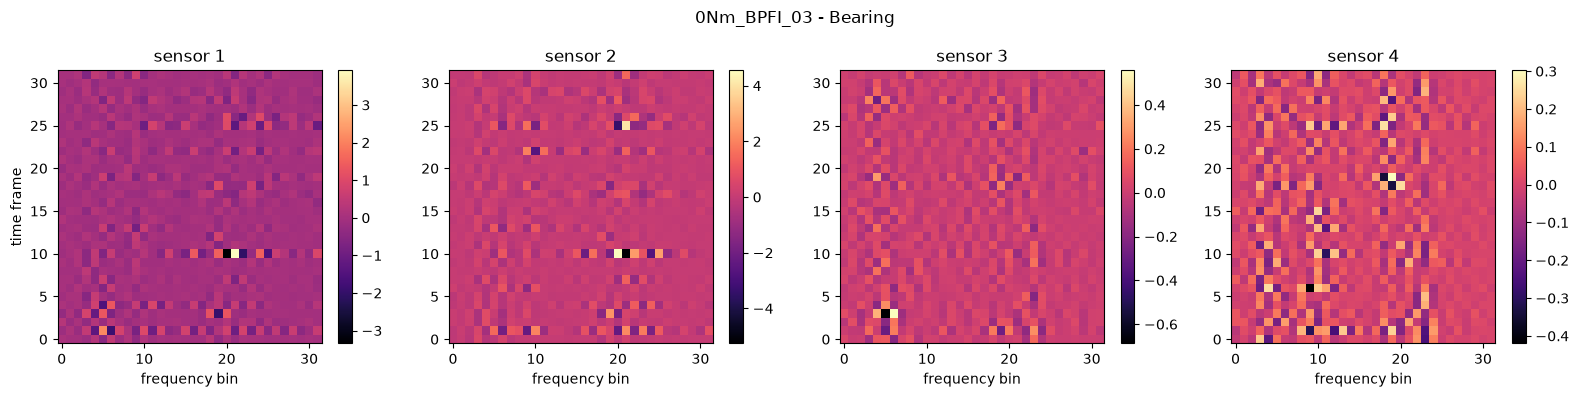

[CHECK] code range across the four sensors: [-172373, 149522] of the +/-8388607 Q9.15 span


In [48]:
# Visual check: one image from each of the four sensors of a single case.
_case = next(case for case in CASES if case.label == 3)
_images = [FRONT_END(read_mem_file(path, max_samples=FRONT_END.samples_per_image))[0]
           for path in _case.sensor_files]

_figure, _axes = plt.subplots(1, N_VIB, figsize=(16, 4))
for _index, (_axis, _image) in enumerate(zip(_axes, _images)):
    _handle = _axis.imshow(q915_to_float(_image), aspect="auto", origin="lower",
                           cmap="magma")
    _axis.set_title(f"sensor {_index + 1}")
    _axis.set_xlabel("frequency bin")
    _axis.set_ylabel("time frame" if _index == 0 else "")
    _figure.colorbar(_handle, ax=_axis)

_figure.suptitle(f"{_case.name} - {CLASS_NAMES[_case.label]}")
plt.tight_layout()
plt.show()

print(f"[CHECK] code range across the four sensors: "
      f"[{min(i.min() for i in _images)}, {max(i.max() for i in _images)}] "
      f"of the +/-{Q915_MAX} Q9.15 span")

### 8. Building the dataset

One image costs `SPEC_FRAMES * FRAME_SIZE * decimation` raw samples per
channel: 65,536 with the decimator (2.56 s of signal), 2,048 without. Each
capture holds 7,680,000 samples, so a case yields at most 117 images with the
decimator on.

**Balancing.** The case mix is badly skewed: three Normal captures against
nine Misalign, fifteen Unbalance and eighteen bearing. Reading the same number
of images from every case hands the network six times more bearing data than
normal data, and the result is a model that scores 70 % overall by never
predicting Normal at all - the one class the arbiter keys on
(`inference_arbiter.sv:83-84` treats anything other than class 2 as a fault).

So `IMAGES_PER_CLASS` is a budget spread across each class's captures rather
than a flat per-case count: three Normal captures each give 96 images, the
eighteen bearing captures give 16 apiece, and every class lands near the same
total. `MAX_IMAGES_PER_CASE` remains the ceiling a single capture may supply.
The loss is class-weighted on top of that.

Both knobs trade build time against dataset size - the front end is the
expensive part and scales linearly with the image count. The result is cached
as one `.npz` keyed by every setting that affects it, so flipping
`USE_DECIMATOR` builds a second cache rather than overwriting the first.

In [49]:
# ============================================================================
# Dataset construction
# ============================================================================
MAX_IMAGES_PER_CASE = 96          # ceiling per capture; 117 are available
IMAGES_PER_CLASS = 288            # budget spread over each class's captures
BALANCE_CLASSES = True


def images_per_case(cases: list[CaptureCase], balance: bool = BALANCE_CLASSES,
                    images_per_class: int = IMAGES_PER_CLASS,
                    cap: int = MAX_IMAGES_PER_CASE) -> dict[int, int]:
    """How many images to draw from each case, keyed by its index in `cases`."""
    budget: dict[int, int] = {}
    for label in range(NUM_CLASSES):
        members = [index for index, case in enumerate(cases) if case.label == label]
        if not members:
            continue
        share = cap if not balance else min(cap, max(1, round(images_per_class / len(members))))
        for index in members:
            budget[index] = share
    return budget


def build_dataset(cases: list[CaptureCase], front_end: SpectrogramFrontEnd,
                  budget: dict[int, int] | None = None
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Builds the image set.

    Returns (features, labels, case_ids): (N, frames, bins, sensors) int32,
    (N,) int64 and (N,) int64. `case_ids` indexes `cases` and exists so the
    train/validation split can keep whole captures on one side.
    """
    budget = budget if budget is not None else images_per_case(cases)
    feature_blocks: list[np.ndarray] = []
    label_blocks: list[np.ndarray] = []
    case_blocks: list[np.ndarray] = []

    for index, case in enumerate(cases):
        wanted = budget.get(index, 0)
        if wanted <= 0:
            continue

        samples_needed = front_end.samples_per_image * wanted
        channels = [front_end(read_mem_file(path, max_samples=samples_needed))
                    for path in case.sensor_files]

        count = min(channel.shape[0] for channel in channels)
        count = min(count, wanted)
        if count == 0:
            print(f"[{index + 1:02d}/{len(cases)}] {case.name:<24s} -> no complete image")
            continue

        stacked = np.stack([channel[:count] for channel in channels], axis=-1)
        feature_blocks.append(stacked.astype(np.int32))
        label_blocks.append(np.full(count, case.label, dtype=np.int64))
        case_blocks.append(np.full(count, index, dtype=np.int64))

        print(f"[{index + 1:02d}/{len(cases)}] {case.name:<24s} -> {count:3d} images "
              f"({CLASS_NAMES[case.label]})")

    if not feature_blocks:
        raise RuntimeError("No images were produced; check the image budget")

    return (np.concatenate(feature_blocks),
            np.concatenate(label_blocks),
            np.concatenate(case_blocks))


def dataset_cache_path(front_end: SpectrogramFrontEnd,
                       budget: dict[int, int]) -> Path:
    """One cache per distinct front end and image budget."""
    total = sum(budget.values())
    tag = (f"dec{int(front_end.use_decimator)}"
           f"_lms{int(front_end.use_lms)}"
           f"_{front_end.source}"
           f"_n{total}")
    return CACHE_DIR / f"spectrograms_{tag}.npz"


def load_or_build_dataset(cases: list[CaptureCase], front_end: SpectrogramFrontEnd,
                          budget: dict[int, int] | None = None,
                          rebuild: bool = False
                          ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Builds the dataset, or reuses the cache built for these exact settings."""
    budget = budget if budget is not None else images_per_case(cases)
    path = dataset_cache_path(front_end, budget)
    if path.is_file() and not rebuild:
        print(f"[DATASET] Reusing {path.name}")
        with np.load(path) as archive:
            return archive["features"], archive["labels"], archive["case_ids"]

    features, labels, case_ids = build_dataset(cases, front_end, budget)
    np.savez_compressed(path, features=features, labels=labels, case_ids=case_ids)
    print(f"[DATASET] Cached {features.shape[0]} images to {path.name}")
    return features, labels, case_ids

In [50]:
BUDGET = images_per_case(CASES)
for _label, _name in enumerate(CLASS_NAMES):
    _members = [i for i, case in enumerate(CASES) if case.label == _label]
    if _members:
        print(f"[BUDGET] {_name:<10s} {len(_members):2d} cases x "
              f"{BUDGET[_members[0]]:3d} images = {sum(BUDGET[i] for i in _members):4d}")

FEATURES, LABELS, CASE_IDS = load_or_build_dataset(CASES, FRONT_END, BUDGET)

print(f"\n[DATASET] features {FEATURES.shape} {FEATURES.dtype}, "
      f"labels {LABELS.shape} {LABELS.dtype}")
print(f"[DATASET] Q9.15 codes span [{FEATURES.min()}, {FEATURES.max()}] "
      f"-> [{q915_to_float(FEATURES.min()):.4f}, {q915_to_float(FEATURES.max()):.4f}]")

_counts = np.bincount(LABELS, minlength=NUM_CLASSES)
for _label, _name in enumerate(CLASS_NAMES):
    _share = 100.0 * _counts[_label] / LABELS.size
    print(f"  {_label} {_name:<10s} {_counts[_label]:5d} images  ({_share:5.1f} %)")

[BUDGET] Normal      3 cases x  96 images =  288
[BUDGET] Unbalance  15 cases x  19 images =  285
[BUDGET] Misalign    9 cases x  32 images =  288
[BUDGET] Bearing    18 cases x  16 images =  288
[01/45] 0Nm_BPFI_03              ->  16 images (Bearing)
[02/45] 0Nm_BPFI_10              ->  16 images (Bearing)
[03/45] 0Nm_BPFI_30              ->  16 images (Bearing)
[04/45] 0Nm_BPFO_03              ->  16 images (Bearing)
[05/45] 0Nm_BPFO_10              ->  16 images (Bearing)
[06/45] 0Nm_BPFO_30              ->  16 images (Bearing)
[07/45] 0Nm_Misalign_01          ->  32 images (Misalign)
[08/45] 0Nm_Misalign_03          ->  32 images (Misalign)
[09/45] 0Nm_Misalign_05          ->  32 images (Misalign)
[10/45] 0Nm_Normal               ->  96 images (Normal)
[11/45] 0Nm_Unbalance_0583mg     ->  19 images (Unbalance)
[12/45] 0Nm_Unbalance_1169mg     ->  19 images (Unbalance)
[13/45] 0Nm_Unbalance_1751mg     ->  19 images (Unbalance)
[14/45] 0Nm_Unbalance_2239mg     ->  19 images (Unbalan

### 9. Dataset wrapper and the float32 twin of `cnn_top`

The network is deliberately tiny because it has to fit the fabric: one 3x3
convolution to eight feature maps, ReLU, a 2x2 max pool, and a single dense
layer to four logits. Nothing else - no batch norm, no second convolution,
no dropout - because `cnn_top` has no hardware for any of it.

The only subtlety is the flatten, and it is the one described in section 3.
`self.pool` produces `(N, 8, 16, 16)`; the permute to `(N, 16, 16, 8)` before
flattening puts the features in `dense_layer_fsm`'s order, so
`dense.weight[class, feature]` exports straight to the ROM with no shuffling.

**Splitting by case, not by image.** Consecutive images inside one capture are
2.56 s windows of the same run under the same fault at the same severity, so
a random image-level split puts near-duplicates on both sides and reports an
accuracy that says nothing about a new machine. `SPLIT_BY_CASE` keeps whole
captures together. It costs several points of reported accuracy and is worth
every one of them; set it False to reproduce the optimistic number.

In [51]:
# ============================================================================
# PyTorch dataset and model
# ============================================================================
class SpectrogramDataset(Dataset):
    """Q9.15 spectrograms held in RAM as float32 tensors, (N, C, H, W)."""

    def __init__(self, features: np.ndarray, labels: np.ndarray):
        scaled = features.astype(np.float32) / np.float32(SCALE)
        self.inputs = torch.from_numpy(scaled).permute(0, 3, 1, 2).contiguous()
        self.targets = torch.from_numpy(labels.astype(np.int64))

    def __len__(self) -> int:
        return int(self.targets.numel())

    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]


class CnnClassifier(nn.Module):
    """Float32 twin of cnn_top."""

    def __init__(self, in_channels: int = N_VIB, conv_channels: int = CONV_CHANNELS,
                 num_classes: int = NUM_CLASSES):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, conv_channels,
                              kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=POOL_SIZE, stride=POOL_SIZE)
        self.dense = nn.Linear(IN_FEATURES, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(self.relu(self.conv(x)))
        # (N, C, H, W) -> (N, H, W, C): dense_layer_fsm walks pixels outermost
        # and the eight pooled channels innermost. See section 3.
        x = x.permute(0, 2, 3, 1).contiguous()
        return self.dense(x.flatten(1))


_preview = CnnClassifier()
_logits = _preview(torch.zeros(1, N_VIB, SPEC_FRAMES, SPEC_BINS))
print(_preview)
print(f"\n[MODEL] logits {tuple(_logits.shape)} (expected (1, {NUM_CLASSES}))")
print(f"[MODEL] conv  {tuple(_preview.conv.weight.shape)} + "
      f"{tuple(_preview.conv.bias.shape)}")
print(f"[MODEL] dense {tuple(_preview.dense.weight.shape)} + "
      f"{tuple(_preview.dense.bias.shape)}")
print(f"[MODEL] parameters: {sum(p.numel() for p in _preview.parameters())}")

CnnClassifier(
  (conv): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dense): Linear(in_features=2048, out_features=4, bias=True)
)

[MODEL] logits (1, 4) (expected (1, 4))
[MODEL] conv  (8, 4, 3, 3) + (8,)
[MODEL] dense (4, 2048) + (4,)
[MODEL] parameters: 8492


### 10. Training

Weighted cross-entropy against inverse class frequency, Adam, a step schedule
that halves the learning rate every fifteen epochs, and early stopping on
validation loss with the best weights restored at the end. The class weights
are load-bearing on top of the image budget: the capture set runs from three
Normal cases to eighteen bearing cases, and an unweighted loss can reach 40 %
by never predicting Normal at all.

**What to expect.** On the balanced set with a case-level split this lands
around 65-70 % overall. Two things in that number are worth understanding
rather than tuning away:

* **Misalign sits at almost exactly 50 %.** Two Misalign captures are held
  out and the model tends to get one entirely right and the other entirely
  wrong, so the recall is a coin flip between captures rather than a per-image
  average. More Misalign captures would move it; more images from the same
  captures will not.
* **Normal is unstable on the real-part spectrogram**, swinging between 0 %
  and 30 % across seeds and landing on 0 % for the default seed. See the table
  in section 7 - this is the front end, not the training.

Only three Normal captures exist in the whole set, and they are three
different torque levels, so a case-level split always validates on an unseen
operating point. That is the honest measurement, and it is a statement about
the capture set rather than about the network.

In [52]:
# ============================================================================
# Training utilities
# ============================================================================
SPLIT_BY_CASE = True
VALIDATION_FRACTION = 0.25


class EarlyStopping:
    """Stops when validation loss stalls, keeping the best weights seen."""

    def __init__(self, patience: int = 10, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.best_state = None
        self.should_stop = False

    def __call__(self, validation_loss: float, model: nn.Module) -> None:
        if validation_loss < self.best_loss - self.delta:
            self.best_loss = validation_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def split_by_case(labels: np.ndarray, case_ids: np.ndarray,
                  validation_fraction: float = VALIDATION_FRACTION,
                  seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    """Holds out whole captures, keeping every class present on both sides."""
    generator = np.random.default_rng(seed)
    validation_cases: list[int] = []

    for label in range(NUM_CLASSES):
        members = np.unique(case_ids[labels == label])
        if members.size == 0:
            continue
        # At least one case held out, and at least one left to train on.
        take = int(round(validation_fraction * members.size))
        take = max(1, min(take, members.size - 1)) if members.size > 1 else 0
        if take:
            validation_cases.extend(generator.permutation(members)[:take].tolist())

    validation_mask = np.isin(case_ids, validation_cases)
    return np.flatnonzero(~validation_mask), np.flatnonzero(validation_mask)


def split_by_image(labels: np.ndarray, validation_fraction: float = VALIDATION_FRACTION,
                   seed: int = SEED) -> tuple[np.ndarray, np.ndarray]:
    """Plain shuffled split. Optimistic: neighbouring images share a capture."""
    generator = np.random.default_rng(seed)
    order = generator.permutation(labels.size)
    cut = int(round((1.0 - validation_fraction) * labels.size))
    return order[:cut], order[cut:]


def class_weights_for(labels: np.ndarray) -> torch.Tensor:
    """Inverse-frequency weights, normalised to a mean of one."""
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float64)
    weights = np.where(counts > 0, labels.size / np.maximum(counts, 1), 0.0)
    weights = weights / weights[weights > 0].mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

In [53]:
# ============================================================================
# Training loop
# ============================================================================
def train_and_evaluate(features: np.ndarray, labels: np.ndarray, case_ids: np.ndarray,
                       epochs: int = 60, batch_size: int = 32,
                       learning_rate: float = 1e-3, patience: int = 10):
    """Trains one CnnClassifier and returns (history, confusion matrix, model)."""
    if SPLIT_BY_CASE:
        train_index, validation_index = split_by_case(labels, case_ids)
        split_kind = "case-level"
    else:
        train_index, validation_index = split_by_image(labels)
        split_kind = "image-level"

    dataset = SpectrogramDataset(features, labels)
    train_loader = DataLoader(Subset(dataset, train_index.tolist()),
                              batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(
        Subset(dataset, validation_index.tolist()),
        batch_size=batch_size, shuffle=False)

    print(f"[TRAIN] {split_kind} split: {train_index.size} train / "
          f"{validation_index.size} validation images")
    print(f"[TRAIN] validation classes: "
          f"{np.bincount(labels[validation_index], minlength=NUM_CLASSES).tolist()}")

    model = CnnClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_for(labels[train_index]))
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=15, gamma=0.5)
    stopper = EarlyStopping(patience=patience)

    history = {"train_loss": [], "train_accuracy": [],
               "validation_loss": [], "validation_accuracy": []}
    best_accuracy = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = correct = seen = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimiser.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimiser.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            seen += inputs.size(0)

        history["train_loss"].append(running_loss / seen)
        history["train_accuracy"].append(correct / seen)

        model.eval()
        running_loss = correct = seen = 0.0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                running_loss += criterion(outputs, targets).item() * inputs.size(0)
                correct += (outputs.argmax(dim=1) == targets).sum().item()
                seen += inputs.size(0)

        validation_loss = running_loss / seen
        validation_accuracy = correct / seen
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_accuracy > best_accuracy:
            best_accuracy = validation_accuracy
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()
        print(f"epoch {epoch + 1:03d}/{epochs:03d} | "
              f"train {history['train_loss'][-1]:.4f} / "
              f"{history['train_accuracy'][-1] * 100:5.2f}% | "
              f"validation {validation_loss:.4f} / {validation_accuracy * 100:5.2f}%")

        stopper(validation_loss, model)
        if stopper.should_stop:
            print(f"[TRAIN] Early stop at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)
    print(f"[TRAIN] Best validation accuracy: {best_accuracy * 100:.2f}%")

    model.eval()
    predictions, truths = [], []
    with torch.no_grad():
        for inputs, targets in validation_loader:
            predictions.extend(model(inputs.to(DEVICE)).argmax(dim=1).cpu().numpy())
            truths.extend(targets.numpy())

    matrix = confusion_matrix(truths, predictions, labels=list(range(NUM_CLASSES)))
    return history, matrix, model

[TRAIN] case-level split: 849 train / 300 validation images
[TRAIN] validation classes: [96, 76, 64, 64]
epoch 001/060 | train 1.1922 / 28.86% | validation 1.1451 / 32.00%
epoch 002/060 | train 0.9859 / 53.47% | validation 1.0003 / 42.33%
epoch 003/060 | train 0.8307 / 61.48% | validation 0.8762 / 56.67%
epoch 004/060 | train 0.7074 / 73.62% | validation 0.8857 / 36.00%
epoch 005/060 | train 0.6245 / 75.85% | validation 0.8658 / 55.67%
epoch 006/060 | train 0.5677 / 78.09% | validation 0.9016 / 53.67%
epoch 007/060 | train 0.5234 / 79.62% | validation 0.8911 / 57.00%
epoch 008/060 | train 0.4849 / 82.10% | validation 0.8869 / 56.33%
epoch 009/060 | train 0.4548 / 83.51% | validation 0.8771 / 53.00%
epoch 010/060 | train 0.4234 / 85.16% | validation 0.8732 / 54.00%
epoch 011/060 | train 0.4007 / 85.39% | validation 0.9538 / 57.33%
epoch 012/060 | train 0.3796 / 86.34% | validation 0.9263 / 53.00%
epoch 013/060 | train 0.3598 / 87.99% | validation 0.9459 / 55.67%
epoch 014/060 | train 0.

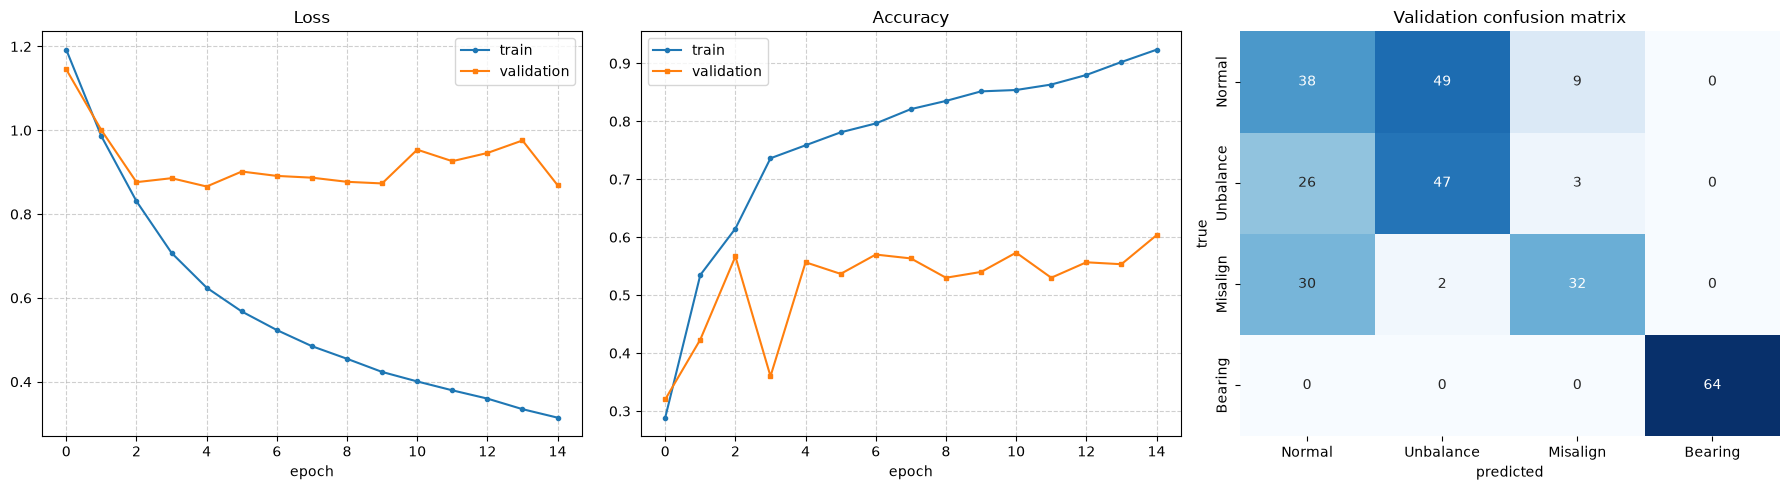

  Normal     recall  39.6%  (96 images)
  Unbalance  recall  61.8%  (76 images)
  Misalign   recall  50.0%  (64 images)
  Bearing    recall 100.0%  (64 images)


In [54]:
HISTORY, CONFUSION, MODEL = train_and_evaluate(FEATURES, LABELS, CASE_IDS, epochs=60)

_figure, _axes = plt.subplots(1, 3, figsize=(18, 5))

_axes[0].plot(HISTORY["train_loss"], label="train", marker="o", markersize=3)
_axes[0].plot(HISTORY["validation_loss"], label="validation", marker="s", markersize=3)
_axes[0].set_title("Loss")
_axes[0].set_xlabel("epoch")
_axes[0].legend()
_axes[0].grid(True, linestyle="--", alpha=0.6)

_axes[1].plot(HISTORY["train_accuracy"], label="train", marker="o", markersize=3)
_axes[1].plot(HISTORY["validation_accuracy"], label="validation", marker="s", markersize=3)
_axes[1].set_title("Accuracy")
_axes[1].set_xlabel("epoch")
_axes[1].legend()
_axes[1].grid(True, linestyle="--", alpha=0.6)

sns.heatmap(CONFUSION, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=_axes[2])
_axes[2].set_title("Validation confusion matrix")
_axes[2].set_xlabel("predicted")
_axes[2].set_ylabel("true")

plt.tight_layout()
plt.show()

for _label, _name in enumerate(CLASS_NAMES):
    _support = CONFUSION[_label].sum()
    _recall = CONFUSION[_label, _label] / _support if _support else float("nan")
    print(f"  {_name:<10s} recall {_recall * 100:5.1f}%  ({_support} images)")

### 11. Exporting the Q9.15 weights

Two artefacts leave this section:

* `cnn_model.pth` and `cnn_model_q915.npz` - the float32 state and the
  quantised integer archive, both kept beside the notebook and both
  gitignored.
* Four `.mem` ROM images, written to every directory in `EXPORT_DIRS`.

The ROM layouts follow the readers:

| file | words | order |
| --- | --- | --- |
| `conv2d_weights.mem` | 288 | `[out_channel][in_channel][row][col]` - `conv2d_fsm.sv:57-64` |
| `conv2d_biases.mem` | 8 | `[out_channel]` |
| `dense_weights.mem` | 8192 | `[class][feature]` - `dense_layer_fsm.sv:104` |
| `dense_biases.mem` | 4 | `[class]` |

Conv weights already match PyTorch's own memory order. Dense weights match
only because the model flattened in hardware order; see section 3.

The one number worth watching in the report below is how many coefficients
quantise to zero. Q9.15 resolves 3.05e-05, so a weight smaller than that
disappears entirely - that, not saturation, is the real risk at this scale.

In [55]:
# ============================================================================
# Q9.15 weight export
# ============================================================================
def export_q915_weights(model: CnnClassifier,
                        state_path: Path = MODEL_STATE_FILE,
                        archive_path: Path = MODEL_Q915_FILE) -> dict[str, np.ndarray]:
    """Saves the float32 state and returns the Q9.15 integer archive."""
    torch.save(model.state_dict(), state_path)
    print(f"[EXPORT] float32 state -> {state_path}")

    tensors = {
        "conv_weights": model.conv.weight,
        "conv_biases": model.conv.bias,
        "dense_weights": model.dense.weight,
        "dense_biases": model.dense.bias,
    }

    quantised: dict[str, np.ndarray] = {}
    for name, tensor in tensors.items():
        values = tensor.detach().cpu().numpy().astype(np.float64)
        codes = float_to_q915(values)
        quantised[name] = codes

        clipped = int(np.count_nonzero((codes == Q915_MIN) | (codes == Q915_MAX)))
        vanished = int(np.count_nonzero((codes == 0) & (values != 0.0)))
        print(f"[EXPORT] {name:<14s} {str(codes.shape):<16s} "
              f"float [{values.min():+.6f}, {values.max():+.6f}]  "
              f"codes [{codes.min()}, {codes.max()}]  "
              f"saturated {clipped}  flushed to zero {vanished}")

    np.savez(archive_path, **quantised)
    print(f"[EXPORT] Q9.15 archive -> {archive_path}")
    return quantised


def to_hex24(value) -> str:
    """Formats a signed integer as 24-bit two's complement hex."""
    return f"{int(value) & ((1 << TOTAL_BITS) - 1):0{HEX_DIGITS}X}"


def write_mem(path: Path, values) -> int:
    """Writes one hex word per line, the format $readmemh expects."""
    flat = np.asarray(values).reshape(-1)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="ascii", newline="\n") as handle:
        for value in flat:
            handle.write(to_hex24(value) + "\n")
    return flat.size


def export_rom_images(quantised: dict[str, np.ndarray],
                      directories: list[Path] = EXPORT_DIRS) -> None:
    """Writes the four ROM images cnn_top loads. See the table in section 11."""
    layout = {
        "conv2d_weights.mem": quantised["conv_weights"],
        "conv2d_biases.mem": quantised["conv_biases"],
        "dense_weights.mem": quantised["dense_weights"],
        "dense_biases.mem": quantised["dense_biases"],
    }
    for directory in directories:
        for filename, values in layout.items():
            written = write_mem(directory / filename, values)
            print(f"[EXPORT] {directory / filename} ({written} words)")

In [56]:
QUANTISED = export_q915_weights(MODEL)
export_rom_images(QUANTISED)

if not any(path == PROJECT_ROOT / "RTL" / "mem" / "cnn" for path in EXPORT_DIRS):
    print("\n[EXPORT] Reminder: RTL/mem/cnn/ is the tracked copy Quartus and "
          "top_system.sv read.\n"
          "         Copy the four .mem files across to promote this model.")

[EXPORT] float32 state -> /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_model.pth
[EXPORT] conv_weights   (8, 4, 3, 3)     float [-0.376280, +0.401032]  codes [-12330, 13141]  saturated 0  flushed to zero 0
[EXPORT] conv_biases    (8,)             float [-0.036268, +0.232410]  codes [-1188, 7616]  saturated 0  flushed to zero 0
[EXPORT] dense_weights  (4, 2048)        float [-0.361311, +0.222092]  codes [-11839, 7278]  saturated 0  flushed to zero 3
[EXPORT] dense_biases   (4,)             float [-0.102614, +0.076037]  codes [-3362, 2492]  saturated 0  flushed to zero 0
[EXPORT] Q9.15 archive -> /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_model_q915.npz
[EXPORT] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/rtl/conv2d_weights.mem (288 words)
[EXPORT] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/rtl/conv2d_biases.mem (8 words)
[EX

### 12. Bit-true golden model

Pure NumPy, integers only, reproducing what the fabric computes rather than
what the float model computes. It exists so a mismatch against the RTL
testbench points at the RTL rather than at the arithmetic.

Every layer follows its module:

* **`Conv2dQ915`** - `conv2d_fsm.sv`. Eight parallel MACs walk the 36 window
  taps, the bias enters the accumulator multiplied by `1 << FRAC_BITS`
  (`conv2d_fsm.sv:172`), and the result is shifted and saturated once at the
  end.
* **`ReluQ915`** - `conv2d_fsm`'s output stage: sign bit set means zero.
* **`MaxPool2x2Q915`** - `maxpool_2x2.sv`, a comparator tree over 2x2.
* **`DenseQ915`** - `dense_layer_fsm.sv`, one MAC per class over all 2048
  features in hardware order.

The MAC deserves care, because the obvious model is wrong. `mac_q8_16.sv`
keeps a **48-bit accumulator of full-width products** and shifts only when the
result is read out. Rounding each product back to 24 bits first, which is what
a naive golden model does, throws away exactly the bits the hardware keeps and
drifts by tens of LSBs across 2048 accumulations. `wrap_signed(..., 48)`
reproduces the accumulator's own wraparound as well.

In [57]:
# ============================================================================
# Bit-true Q9.15 golden model
# ============================================================================
def mac_q915(accumulator):
    """Reads a mac_q8_16 accumulator out: wrap at 48 bits, shift, saturate."""
    return saturate(wrap_signed(accumulator, ACC_BITS) >> FRAC_BITS)


class Conv2dQ915:
    """conv2d_fsm.sv: 3x3 correlation over IN_CHANNELS, zero padding of 1."""

    def __init__(self, weights: np.ndarray, biases: np.ndarray,
                 kernel_size: int = 3, padding: int = 1):
        self.weights = np.asarray(weights, dtype=np.int64)
        self.biases = np.asarray(biases, dtype=np.int64)
        self.kernel_size = kernel_size
        self.padding = padding

    def forward(self, image: np.ndarray) -> np.ndarray:
        """(H, W, IC) -> (H, W, OC), all Q9.15."""
        height, width, _ = image.shape
        out_channels = self.weights.shape[0]

        padded = np.pad(image.astype(np.int64),
                        ((self.padding, self.padding),
                         (self.padding, self.padding), (0, 0)))
        # (H, W, IC, k, k), matching weights.reshape(OC, IC * k * k).
        windows = sliding_window_view(padded, (self.kernel_size, self.kernel_size),
                                      axis=(0, 1))
        patches = windows.reshape(height * width, -1)

        kernels = self.weights.reshape(out_channels, -1)
        accumulator = patches @ kernels.T
        accumulator = accumulator + (self.biases << FRAC_BITS)
        return mac_q915(accumulator).reshape(height, width, out_channels)


class ReluQ915:
    """Zeroes anything with the sign bit set."""

    def forward(self, image: np.ndarray) -> np.ndarray:
        return np.maximum(image, 0)


class MaxPool2x2Q915:
    """maxpool_2x2.sv: non-overlapping 2x2 maximum."""

    def __init__(self, pool_size: int = POOL_SIZE):
        self.pool_size = pool_size

    def forward(self, image: np.ndarray) -> np.ndarray:
        height, width, channels = image.shape
        size = self.pool_size
        reshaped = image.reshape(height // size, size, width // size, size, channels)
        return reshaped.max(axis=(1, 3))


class DenseQ915:
    """dense_layer_fsm.sv: one MAC per class over the flattened feature map."""

    def __init__(self, weights: np.ndarray, biases: np.ndarray):
        self.weights = np.asarray(weights, dtype=np.int64)
        self.biases = np.asarray(biases, dtype=np.int64)

    def forward(self, features: np.ndarray) -> np.ndarray:
        accumulator = self.weights @ features.astype(np.int64)
        accumulator = accumulator + (self.biases << FRAC_BITS)
        return mac_q915(accumulator)


class CnnGoldenModel:
    """The whole of cnn_top, in integers."""

    def __init__(self, quantised: dict[str, np.ndarray]):
        self.conv = Conv2dQ915(quantised["conv_weights"], quantised["conv_biases"])
        self.relu = ReluQ915()
        self.pool = MaxPool2x2Q915()
        self.dense = DenseQ915(quantised["dense_weights"], quantised["dense_biases"])

    @classmethod
    def from_archive(cls, path: Path = MODEL_Q915_FILE) -> "CnnGoldenModel":
        with np.load(path) as archive:
            return cls({name: archive[name] for name in archive.files})

    def forward(self, image: np.ndarray) -> np.ndarray:
        """(SPEC_FRAMES, SPEC_BINS, N_VIB) Q9.15 -> (NUM_CLASSES,) Q9.15 logits."""
        pooled = self.pool.forward(self.relu.forward(self.conv.forward(image)))
        # Row-major over (H, W, C) is exactly dense_layer_fsm's feature order.
        return self.dense.forward(pooled.reshape(-1))

### 13. Golden run and the testbench stimulus

The image below is drawn from a **held-out capture** so the comparison is not
made against something the network memorised. Three things are checked:

1. the float model and the golden model agree on the predicted class;
2. their logits agree to within the quantisation error;
3. the stimulus written for `tb_smma_cnn_top.sv` is the same image the golden
   logits came from.

`cnn_tb_input.mem` is flattened `(32, 32, 4)` in C order, so the file reads
`pixel0_ch0..ch3, pixel1_ch0..ch3, ...` - which is how the testbench indexes
it at `tb_smma_cnn_top.sv:63-66`. Run the testbench and the four logits it
prints should match the ones printed here.

In [58]:
# ============================================================================
# Golden model run and testbench export
# ============================================================================
def export_tb_input(image: np.ndarray, path: Path = TB_INPUT_FILE) -> None:
    """Writes one spectrogram as the testbench stimulus."""
    if image.shape != (SPEC_FRAMES, SPEC_BINS, N_VIB):
        raise ValueError(f"Expected {(SPEC_FRAMES, SPEC_BINS, N_VIB)}, got {image.shape}")
    written = write_mem(path, image.reshape(-1))
    print(f"[TB] {path} ({written} channel-pixels)")


# Same seed, same split, so this really is a held-out capture.
if SPLIT_BY_CASE:
    _, _validation_index = split_by_case(LABELS, CASE_IDS)
else:
    _, _validation_index = split_by_image(LABELS)

_sample = int(_validation_index[0])
_image = FEATURES[_sample].astype(np.int64)
_truth = int(LABELS[_sample])
_case_name = CASES[int(CASE_IDS[_sample])].name

GOLDEN_MODEL = CnnGoldenModel(QUANTISED)
_golden_logits = GOLDEN_MODEL.forward(_image)

MODEL.eval()
with torch.no_grad():
    _tensor = torch.from_numpy(
        q915_to_float(_image).astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
    _float_logits = MODEL(_tensor.to(DEVICE)).cpu().numpy()[0]

_golden_class = int(np.argmax(_golden_logits))
_float_class = int(np.argmax(_float_logits))

print(f"[GOLDEN] sample {_sample} from {_case_name} (true class: {CLASS_NAMES[_truth]})")
print(f"{'class':<12s}{'float32':>12s}{'golden':>12s}{'golden code':>14s}")
for _index, _name in enumerate(CLASS_NAMES):
    print(f"{_name:<12s}{_float_logits[_index]:>12.5f}"
          f"{q915_to_float(_golden_logits[_index]):>12.5f}"
          f"{int(_golden_logits[_index]):>14d}")

print(f"\n[GOLDEN] float32 predicts {CLASS_NAMES[_float_class]}, "
      f"golden predicts {CLASS_NAMES[_golden_class]}")
print(f"[GOLDEN] argmax agrees: {_float_class == _golden_class}")
print(f"[GOLDEN] max logit error: "
      f"{np.abs(q915_to_float(_golden_logits) - _float_logits).max():.6f}")

export_tb_input(_image)

[GOLDEN] sample 32 from 0Nm_BPFI_30 (true class: Bearing)
class            float32      golden   golden code
Normal         -59.44483   -59.44348      -1947844
Unbalance      -32.07306   -32.07230      -1050945
Misalign         9.69671     9.69647        317734
Bearing         19.25123    19.25046        630799

[GOLDEN] float32 predicts Bearing, golden predicts Bearing
[GOLDEN] argmax agrees: True
[GOLDEN] max logit error: 0.001347
[TB] /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/cnn_tb_input.mem (4096 channel-pixels)


### 14. Checklist before running the RTL

1. `FRAC_BITS` is 15 in `mac_q8_16.sv`, `cnn_top.sv`, `conv2d_fsm.sv`,
   `dense_layer_fsm.sv` and the four CNN testbenches. It is still 16 today.
2. The four `.mem` files have been copied from `Scripts/cnn/rtl/` to
   `RTL/mem/cnn/`, which is what `top_system.sv:40-43` and the `.qsf` read.
3. `cnn_tb_input.mem` sits beside this notebook, where
   `tb_smma_cnn_top.sv:27` looks for it.
4. The logits printed in section 13 are the ones the testbench should print.